# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Adam Kevin
- **Email:** adamkevin514@gmail.com
- **ID Dicoding:** 	CDCC009D6Y0748

## Menentukan Pertanyaan Bisnis

- Bagaimana karakteristik pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) dan bagaimana segmentasi pelanggan yang terbentuk?

- Produk atau kategori produk apa yang paling berkontribusi terhadap total penjualan dan jumlah transaksi?

- Bagaimana tren penjualan dari waktu ke waktu, dan apakah terdapat pola tertentu dalam aktivitas transaksi pelanggan?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Data manipulation & analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & time handling
import datetime as dt

# Optional (biar visual lebih bagus)
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Data Wrangling

### Gathering Data



Pada tahap ini dilakukan proses pengumpulan data yang akan digunakan dalam analisis. Dataset yang digunakan adalah **E-Commerce Public Dataset**, yang berisi informasi terkait transaksi pelanggan, produk, pembayaran, serta data pelanggan.

Data ini terdiri dari beberapa file yang saling berelasi, seperti data orders, customers, products, dan order items. Seluruh data akan dimuat ke dalam environment untuk selanjutnya dilakukan proses pembersihan dan analisis lebih lanjut.

In [2]:
from google.colab import files
import zipfile
import io

uploaded = files.upload()


with zipfile.ZipFile(io.BytesIO(uploaded['E-commerce-public-dataset.zip']), 'r') as zip_ref:
    zip_ref.extractall()

Saving E-commerce-public-dataset.zip to E-commerce-public-dataset.zip


In [3]:
#Dataset Utama
customers_df = pd.read_csv('E-Commerce Public Dataset/customers_dataset.csv')
orders_df = pd.read_csv('E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('E-Commerce Public Dataset/order_items_dataset.csv')
payments_df = pd.read_csv('E-Commerce Public Dataset/order_payments_dataset.csv')
products_df = pd.read_csv('E-Commerce Public Dataset/products_dataset.csv')

# Dataset tambahan
category_df = pd.read_csv('E-Commerce Public Dataset/product_category_name_translation.csv')

In [4]:
# Preview dataset
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [8]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**

## Insight Data Gathering

Berdasarkan proses data gathering dan preview seluruh dataset, dapat disimpulkan bahwa data yang digunakan terdiri dari beberapa tabel yang saling berelasi, seperti data pelanggan, transaksi, produk, dan pembayaran.

Setiap dataset memiliki peran yang berbeda namun saling melengkapi, sehingga memungkinkan analisis yang komprehensif terkait perilaku pelanggan, performa produk, serta nilai transaksi.

Selain itu, terdapat dataset tambahan yang berfungsi untuk meningkatkan keterbacaan kategori produk, sehingga hasil analisis nantinya dapat lebih mudah dipahami.

### Assessing Data

Data Customers

In [10]:
customers_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [11]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [12]:
customers_df.duplicated().sum()

np.int64(0)

Data Order

In [13]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [14]:
orders_df.isna().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [15]:
orders_df.duplicated().sum()

np.int64(0)

Data Order Item

In [16]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [17]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [18]:
order_items_df.duplicated().sum()

np.int64(0)

Data Payment

In [19]:
payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [20]:
payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [21]:
payments_df.duplicated().sum()

np.int64(0)

Data Produk

In [22]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [23]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [24]:
products_df.duplicated().sum()

np.int64(0)

Data Kategori

In [25]:
category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [26]:
category_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [27]:
category_df.duplicated().sum()

np.int64(0)

**Insight:**

Berdasarkan proses pemeriksaan kualitas data yang telah dilakukan terhadap seluruh dataset, diperoleh beberapa temuan sebagai berikut:

- Dataset customers, order items, payments, dan product category translation tidak memiliki missing values maupun data duplikat, sehingga dapat langsung digunakan untuk proses analisis.
- Dataset orders memiliki beberapa missing values pada kolom terkait waktu pengiriman, yang kemungkinan disebabkan oleh pesanan yang belum selesai atau tidak berstatus "delivered".
- Dataset products memiliki jumlah missing values yang cukup signifikan, terutama pada informasi kategori dan atribut produk, sehingga memerlukan penanganan lebih lanjut pada tahap data cleaning.
- Beberapa kolom bertipe waktu pada dataset orders dan order items masih dalam format object, sehingga perlu dikonversi ke tipe datetime agar dapat digunakan untuk analisis berbasis waktu.

Secara keseluruhan, data yang digunakan memiliki kualitas yang cukup baik, namun tetap memerlukan proses pembersihan dan transformasi untuk memastikan hasil analisis yang lebih akurat dan optimal.

### Cleaning Data

Convert waktu ke datetime

In [28]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])



Handle Missing Values di data Orders

In [29]:

# Missing values pada kolom terkait pengiriman tidak dihapus
# karena masih memiliki makna (misalnya pesanan belum selesai atau belum dikirim)

# Namun, untuk analisis tertentu, kita bisa memfilter hanya order yang sudah selesai
delivered_orders_df = orders_df[orders_df['order_status'] == 'delivered']

Handle Missing Values di data Products

In [30]:
# Isi kategori yang kosong dengan 'unknown'
products_df['product_category_name'].fillna('unknown', inplace=True)

# Untuk kolom numerik, isi dengan median
products_df['product_name_lenght'].fillna(products_df['product_name_lenght'].median(), inplace=True)
products_df['product_description_lenght'].fillna(products_df['product_description_lenght'].median(), inplace=True)
products_df['product_photos_qty'].fillna(products_df['product_photos_qty'].median(), inplace=True)

products_df['product_weight_g'].fillna(products_df['product_weight_g'].median(), inplace=True)
products_df['product_length_cm'].fillna(products_df['product_length_cm'].median(), inplace=True)
products_df['product_height_cm'].fillna(products_df['product_height_cm'].median(), inplace=True)
products_df['product_width_cm'].fillna(products_df['product_width_cm'].median(), inplace=True)

/tmp/ipykernel_12222/1882002251.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name'].fillna('unknown', inplace=True)
/tmp/ipykernel_12222/1882002251.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

**Insight:**


Pada tahap data cleaning, dilakukan beberapa proses untuk meningkatkan kualitas data sebelum dianalisis lebih lanjut.

Kolom bertipe waktu pada dataset orders dan order items telah dikonversi ke format datetime agar dapat digunakan dalam analisis berbasis waktu. Selain itu, missing values pada dataset products ditangani dengan metode imputasi, yaitu mengisi nilai kategori dengan "unknown" serta menggunakan nilai median untuk kolom numerik.

Sementara itu, missing values pada dataset orders tidak dihapus karena masih memiliki makna, seperti pesanan yang belum selesai atau belum dikirim.

Secara keseluruhan, proses data cleaning ini membuat data menjadi lebih konsisten dan siap digunakan untuk tahap analisis selanjutnya.

## Exploratory Data Analysis (EDA)

Explore Tren Order per Bulan

In [31]:
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders_df.groupby('order_month')['order_id'].count().reset_index()
monthly_orders.head()

,order_month,order_id
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


Explore Revenue per Kategori

In [32]:
merge_df = pd.merge(order_items_df, products_df, on='product_id')
merge_df = pd.merge(merge_df, payments_df, on='order_id')

revenue_per_category = merge_df.groupby('product_category_name')['payment_value'].sum().reset_index()
revenue_per_category.sort_values(by='payment_value', ascending=False).head()

,product_category_name,payment_value
13,cama_mesa_banho,1712553.67
11,beleza_saude,1657373.12
44,informatica_acessorios,1585330.45
54,moveis_decoracao,1430176.39
66,relogios_presentes,1429216.68


Explore Distribusi Metode Pembayaran

In [33]:
payment_type_dist = payments_df['payment_type'].value_counts().reset_index()
payment_type_dist.columns = ['payment_type', 'count']
payment_type_dist

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


Jumlah order per kota

In [34]:
orders_customers = pd.merge(orders_df, customers_df, on='customer_id')

city_orders = orders_customers['customer_city'].value_counts().reset_index()
city_orders.columns = ['customer_city', 'total_orders']
city_orders.head()

,customer_city,total_orders
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521


**Insight:**




Berdasarkan hasil eksplorasi data awal, terdapat beberapa pola yang mulai terlihat:

- Jumlah pesanan menunjukkan adanya peningkatan dari waktu ke waktu, terutama sejak tahun 2017, yang mengindikasikan pertumbuhan aktivitas transaksi.
- Beberapa kategori produk seperti cama_mesa_banho, beleza_saude, dan informatica_acessorios memiliki kontribusi penjualan yang cukup besar dibandingkan kategori lainnya.
- Metode pembayaran didominasi oleh penggunaan credit card, diikuti oleh boleto, sementara metode lainnya digunakan dalam jumlah yang lebih kecil.
- Kota-kota besar seperti Sao Paulo dan Rio de Janeiro memiliki jumlah pesanan yang jauh lebih tinggi dibandingkan kota lainnya.

Temuan ini menunjukkan adanya pola awal yang menarik dan akan dianalisis lebih lanjut pada tahap visualisasi dan explanatory analysis.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana tren penjualan dari waktu ke waktu, dan apakah terdapat pola tertentu dalam aktivitas transaksi pelanggan?

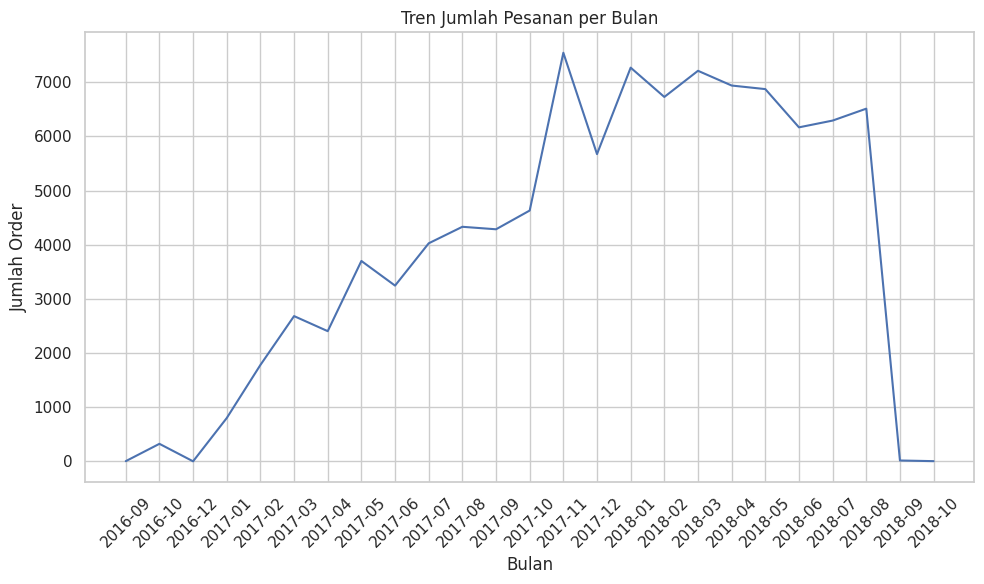

In [37]:
import matplotlib.pyplot as plt

# Tren order per bulan
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders_df.groupby('order_month')['order_id'].count().reset_index()

monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

plt.figure()
plt.plot(monthly_orders['order_month'], monthly_orders['order_id'])
plt.xticks(rotation=45)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.title('Tren Jumlah Pesanan per Bulan')
plt.tight_layout()
plt.show()

### Pertanyaan 2:

Produk atau kategori produk apa yang paling berkontribusi terhadap total penjualan dan jumlah transaksi?

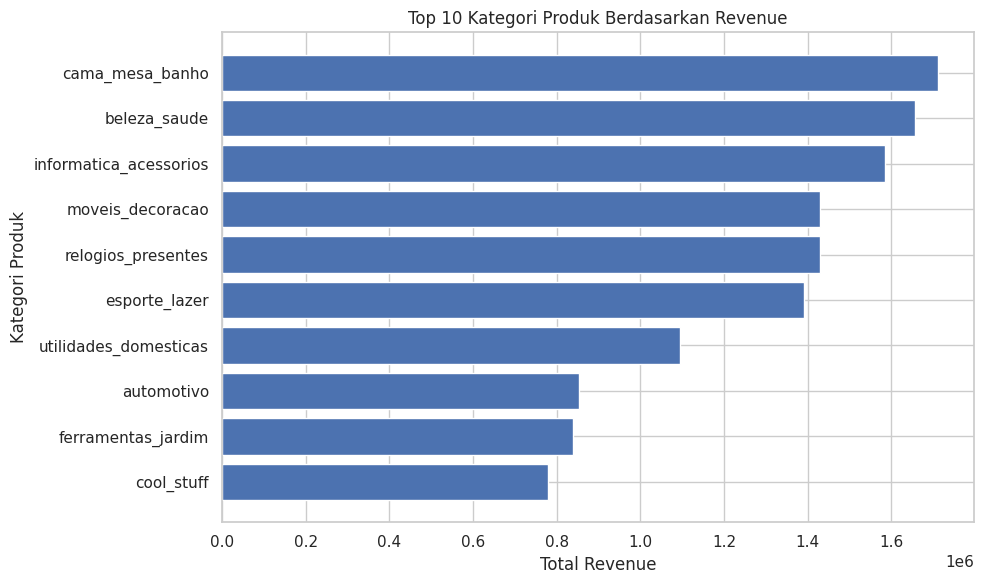

In [38]:
# Merge data
merge_df = pd.merge(order_items_df, products_df, on='product_id')
merge_df = pd.merge(merge_df, payments_df, on='order_id')

# Analisis produk
product_analysis = merge_df.groupby('product_category_name').agg({
    'payment_value': 'sum',
    'order_id': 'count'
}).reset_index()

top_category = product_analysis.sort_values(by='payment_value', ascending=False).head(10)

# Plot
plt.figure()
plt.barh(top_category['product_category_name'], top_category['payment_value'])
plt.xlabel('Total Revenue')
plt.ylabel('Kategori Produk')
plt.title('Top 10 Kategori Produk Berdasarkan Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Pertanyaan 3:
Bagaimana karakteristik pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) dan bagaimana segmentasi pelanggan yang terbentuk?

In [39]:
# Merge orders + payments
rfm_df = pd.merge(orders_df, payments_df, on='order_id')

# Filter delivered
rfm_df = rfm_df[rfm_df['order_status'] == 'delivered']

# Agregasi per order
rfm_df = rfm_df.groupby(['order_id', 'customer_id', 'order_purchase_timestamp'], as_index=False).agg({
    'payment_value': 'sum'
})

# Hitung RFM
recent_date = rfm_df['order_purchase_timestamp'].max()

rfm = rfm_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

In [42]:
# Buat skor berdasarkan quantile
rfm['R_score'] = pd.qcut(rfm['Recency'], 3, labels=[3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1,2,3])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 3, labels=[1,2,3])

# Gabungkan skor
rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

# Segmentasi
def segment(score):
    if score >= 8:
        return 'High Value'
    elif score >= 5:
        return 'Loyal'
    else:
        return 'Regular'

rfm['Segment'] = rfm['RFM_score'].apply(segment)

rfm['Segment'].value_counts()

,count
Segment,
Loyal,67349
High Value,14629
Regular,14499


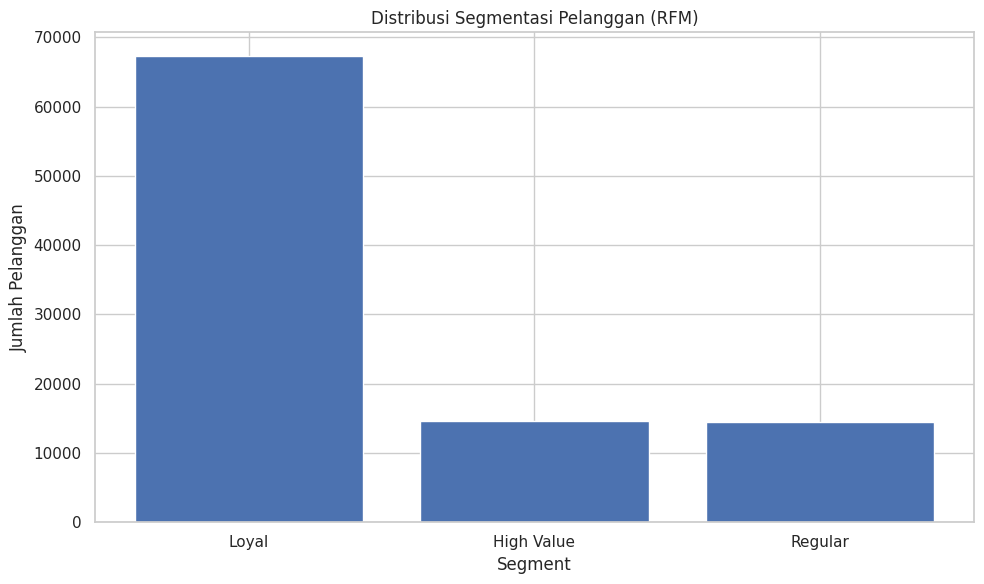

In [43]:
segment_count = rfm['Segment'].value_counts()

plt.figure()
plt.bar(segment_count.index, segment_count.values)
plt.xlabel('Segment')
plt.ylabel('Jumlah Pelanggan')
plt.title('Distribusi Segmentasi Pelanggan (RFM)')
plt.tight_layout()
plt.show()

**Insight**

Berdasarkan hasil visualisasi dan analisis yang telah dilakukan, diperoleh beberapa insight utama sebagai berikut:

- Tren penjualan menunjukkan peningkatan yang signifikan sejak tahun 2017 hingga mencapai puncaknya, kemudian cenderung stabil pada tahun 2018. Penurunan pada periode akhir kemungkinan disebabkan oleh data yang belum lengkap.
- Kategori produk seperti cama_mesa_banho, beleza_saude, dan informatica_acessorios merupakan kontributor utama terhadap total revenue dan jumlah transaksi, yang menunjukkan tingginya permintaan pada kategori tersebut.
- Berdasarkan analisis RFM, pelanggan dapat dikelompokkan menjadi tiga segmen utama yaitu High Value, Loyal, dan Regular. Mayoritas pelanggan berada pada segmen Loyal, yang menunjukkan adanya tingkat retensi pelanggan yang cukup baik.

Secara keseluruhan, bisnis menunjukkan pertumbuhan yang positif dengan didukung oleh kategori produk unggulan serta basis pelanggan yang cukup loyal.

## Analisis Lanjutan (Opsional)

Analisis lanjutan dilakukan menggunakan metode RFM (Recency, Frequency, Monetary) untuk memahami perilaku pelanggan berdasarkan aktivitas transaksi.

In [44]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,Segment,R_score,F_score,M_score,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,287,1,114.74,Loyal,2,1,2,5
1,000161a058600d5901f007fab4c27140,409,1,67.41,Regular,1,1,1,3
2,0001fd6190edaaf884bcaf3d49edf079,547,1,195.42,Loyal,1,1,3,5
3,0002414f95344307404f0ace7a26f1d5,378,1,179.35,Loyal,1,1,3,5
4,000379cdec625522490c315e70c7a9fb,149,1,107.01,Loyal,3,1,2,6


Analisis ini menunjukkan bahwa pelanggan dapat dikelompokkan menjadi beberapa segmen dengan karakteristik berbeda, yang dapat digunakan sebagai dasar strategi pemasaran.

## Conclusion

- Conclution pertanyaan 1

Berdasarkan visualisasi tren jumlah pesanan per bulan, terlihat bahwa terjadi peningkatan jumlah transaksi secara signifikan sejak awal tahun 2017 hingga mencapai puncaknya pada akhir tahun 2017.

Setelah itu, jumlah pesanan cenderung stabil dengan fluktuasi kecil sepanjang tahun 2018. Namun, terlihat penurunan drastis pada bulan-bulan terakhir, yang kemungkinan disebabkan oleh data yang belum lengkap (incomplete data) pada periode tersebut.

Secara keseluruhan, pola ini menunjukkan adanya pertumbuhan bisnis yang cukup pesat di awal periode, kemudian memasuki fase stabil.

- Conclution pertanyaan 2

Berdasarkan visualisasi top 10 kategori produk berdasarkan revenue, terlihat bahwa kategori cama_mesa_banho, beleza_saude, dan informatica_acessorios merupakan kontributor utama terhadap total penjualan.

Kategori-kategori tersebut memiliki nilai revenue yang secara signifikan lebih tinggi dibandingkan kategori lainnya, yang menunjukkan tingginya permintaan pelanggan pada produk-produk tersebut.

Selain itu, terdapat beberapa kategori lain seperti moveis_decoracao dan relogios_presentes yang juga memberikan kontribusi cukup besar, meskipun tidak sebesar tiga kategori teratas.

Hal ini menunjukkan bahwa penjualan tidak hanya terpusat pada satu kategori saja, melainkan tersebar pada beberapa kategori utama yang menjadi pendorong utama revenue.

 - Conclution Pertanyaan 3

 Berdasarkan hasil analisis RFM, pelanggan dapat dikelompokkan menjadi tiga segmen utama yaitu High Value, Loyal, dan Regular.

Sebagian besar pelanggan berada pada segmen Loyal, yang menunjukkan bahwa banyak pelanggan melakukan pembelian secara berulang dan memiliki keterlibatan yang cukup baik dengan platform.

Selain itu, terdapat segmen High Value yang meskipun jumlahnya lebih sedikit, memberikan kontribusi besar terhadap total revenue. Sementara itu, segmen Regular menunjukkan pelanggan dengan aktivitas transaksi yang relatif rendah.

Hasil ini menunjukkan bahwa bisnis memiliki basis pelanggan yang cukup loyal, serta peluang untuk meningkatkan nilai pelanggan pada segmen Regular melalui strategi pemasaran yang lebih terarah.